In this notebook, we try to solve the one norm problem with cost function 

\begin{equation}
    J(u) = \|Au - b\|_2^2 + \alpha \|u\|_1
\end{equation}

by rewriting it into a least squares problem and using CIL build in functions to minimize 
the least squares problem. In each iteration, the least squares problem is

\begin{equation*}
    u_{k+1} = \arg\min_u \left\| \begin{bmatrix}
        A\\
        \lambda W^{(k)}
    \end{bmatrix}u - \begin{bmatrix}
        b\\
        0
    \end{bmatrix}\right\|_2^2
\end{equation*}

with $W^{(k)} = \text{diag}\{u^{(k)^{-1/2}}\}$

In [12]:
# import necessary packages

# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.functions import LeastSquares, IndicatorBox, L2NormSquared
from cil.optimisation.utilities import callbacks

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, MaskOperator

In [13]:
# setting pixels and angles
n_pixels = 265
n_angles = 50

## Setting up the phantom, sinogram, imagedata, etc.

In [14]:
# Set logging level for CIL processors:
logging.basicConfig(level=logging.WARNING)
cil_log_level = logging.getLogger('cil.processors')
cil_log_level.setLevel(logging.INFO)

# Setting background defaults
cmap = "rainbow"
device = "cpu"

In [15]:
# Angles
angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

# Setup acquisition geometry
ag = AcquisitionGeometry.create_Parallel2D()\
                            .set_angles(angles)\
                            .set_panel(n_pixels, pixel_size=1/n_pixels)

# Setup image geometry
ig = ImageGeometry(voxel_num_x=n_pixels, 
                   voxel_num_y=n_pixels, 
                   voxel_size_x=1/n_pixels, 
                   voxel_size_y=1/n_pixels)

# Get phantom
phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

# Create projection operator using Astra-Toolbox.
A = ProjectionOperator(ig, ag, device)

# Create an acquisition data (numerically)
sino = A.direct(phantom)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


In [16]:
def get_A(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry

    # Note that if number of pixels and number of angels are equal, 
    # the matrix is square and an exact solution can be found, 
    # then there is a sufficient number of pojections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device='cpu')

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    return A, sino, ig, ag, phantom


def add_poss_noise(background_counts, n_angles, n_pixels):
    A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

    # adding noise to the sinogram

    # Convert the simulated absorption sinogram to transmission values using Lambert-Beer. 
    counts_poss = background_counts * np.exp(-sino.as_array())

    # Use as a mean for Poisson data generation.
    noisy_counts_poss = np.random.poisson(counts_poss)
    nonzero = noisy_counts_poss > 0

    # Convert back to absorption sinogram.
    sino_out_poss = np.zeros_like(sino.as_array())
    sino_out_poss[nonzero] = -np.log(noisy_counts_poss[nonzero]/ background_counts)

    # allocate sino_noisy and fill with noisy data
    sino_noisy_poss = ag.allocate()
    sino_noisy_poss.fill(sino_out_poss)

    return sino_noisy_poss

## Creating block algorithm

In underneath function, cgls is used to minimize the least squares problem

In [17]:
def onenorm_cgls(initial, inner_iter, outer_iter, A, sino, alpha, er):

    """
    Function that minimises the cost function 

    J(u) = ||Ru - b||_2^2 + ||u||_1

    by minimising 

    J(u) = ||Ru - b||_2^2 + ||W_k u||_2^2

    via the BlockFramework and the cgls function from CIL. the matrix W_k is reweighted in each iteration
    with W_k = u_k**(-1/2)

    Input
        Initial:    initial guess for u (ImageData)
        inner_iter: maximum number of iterations for cgls (integer)
        outer_iter: maximum number of iterations to reweight W_k (integer)
        A:          operator R (ProjectionOperator)
        sino:       lhs of the data fidelity term, 'b' (ImageData)
        alpha:      regularisation parameter (float)
        er:         lower bound for values in W_k to be considered to reweight, 
                    low values will be set to zero (float)

    Output
        uk:         reconstructed image (ImageData)
    """

    uk = initial.copy()
    for k in range(outer_iter):

        print("Outer iteration:", k + 1)
        
        ## reweight the regularisation term ##
        
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = uk_grad_np[large_values] ** (-1/2)

        # convert back to ImageData
        uk_reweighted = ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        ## setting up minimisation functional in BlockFramework ##

        # set W
        w_operator = DiagonalOperator(uk_reweighted)

        # create block operator
        operator_block = BlockOperator(A, np.sqrt(alpha)*w_operator)

        # create block data container
        zero_block = w_operator.range.allocate(0)
        data_block = BlockDataContainer(sino, zero_block)

        # solver inner minimization problem 
        cgls = CGLS(initial=uk, operator=operator_block, data=data_block, update_objective_interval=1)

        # CGLS EarlyStopping terminates CG when ||..._k|| < epsilon*||..._0||
        cgls.run(inner_iter, verbose=0, callbacks=[callbacks.ProgressCallback(), 
                                                   callbacks.CGLSEarlyStopping(epsilon=1e-6)])
        uk = cgls.solution

    return uk

In [18]:
x0 = ig.allocate(0)
alpha = 5e-6

The forward error decreases when er gets smaller. However, for er = 0, the forward error is very large

Outer iteration: 1


  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 2


  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 3


...

  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 19


  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 20


  0%|          | 0/10 [00:00<?, ?it/s]

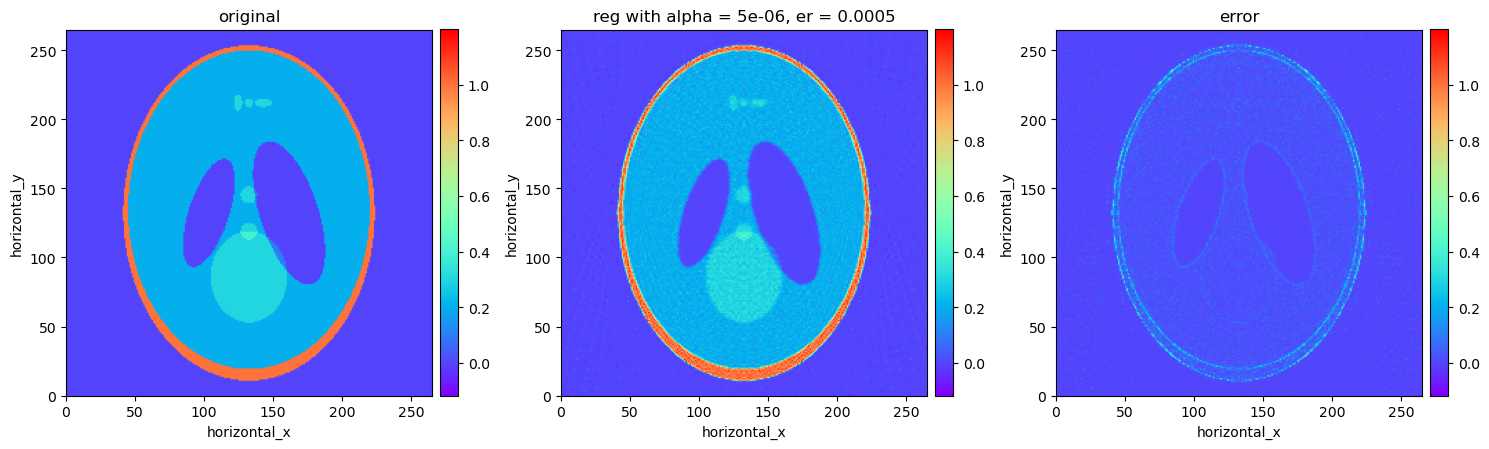

Forward error: 110.50958502318531


In [19]:
norm = L2NormSquared()
for er in [0.0005]:
       
       recon = onenorm_cgls(x0, 10, 20, A, sino, alpha, er)
       error = phantom - recon
       show2D([phantom, recon, error.abs()], ['original', f'reg with alpha = {alpha}, er = {er}', 'error'], 
       cmap=cmap, num_cols = 3, fix_range=True)

       print("Forward error:", norm(error))

## Final code

In [ ]:
def onenorm_cgls(initial, inner_iter, outer_iter, A, sino, alpha, er, cg_tol, exact):

    """
    Function that minimises the cost function 

    J(u) = ||Ru - b||_2^2 + ||u||_1

    by minimising 

    J(u) = ||Ru - b||_2^2 + ||W_k u||_2^2

    via the BlockFramework and the cgls function from CIL. the matrix W_k is reweighted in each iteration
    with W_k = u_k**(-1/2)

    Input
        Initial:    initial guess for u (ImageData)
        inner_iter: maximum number of iterations for cgls (integer)
        outer_iter: maximum number of iterations to reweight W_k (integer)
        A:          operator R (ProjectionOperator)
        sino:       lhs of the data fidelity term, 'b' (ImageData)
        alpha:      regularisation parameter (float)
        er:         lower bound for values in W_k to be considered to reweight, 
                    low values will be set to zero (float)
        cg_tol:     tolerance for cg (float)
        exact:      if known, the exact solution to the reconstruction problem (ImageData), 
                    if not known, put None and the backward error is computed

    Output
        uk:         reconstructed image (ImageData)
        err:        backward error or forward error depending on what is inputted in 'exact' (numpy array)
    """

    uk = initial.copy()
    get_ig = A.domain_geometry()

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    err = []
    norm = L2NormSquared()
    norm_b = norm(sino)

    if exact == None:
        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    for k in range(outer_iter):

        print("Outer iteration:", k + 1)
        
        ## reweight the regularisation term ##
        
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2**(1/2)*(uk_grad_np[large_values] ** (-1/2))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        ## setting up minimisation functional in BlockFramework ##

        # set W
        w_operator = DiagonalOperator(uk_reweighted)

        # create block operator
        operator_block = BlockOperator(A, np.sqrt(alpha)*w_operator)

        # create block data container
        zero_block = w_operator.range.allocate(0)
        data_block = BlockDataContainer(sino, zero_block)

        # solver inner minimization problem 
        cgls = CGLS(initial=uk, operator=operator_block, data=data_block, update_objective_interval=1)

        # CGLS EarlyStopping terminates CG when ||..._k|| < epsilon*||..._0||
        cgls.run(inner_iter, verbose=0, callbacks=[callbacks.ProgressCallback(), 
                                                   callbacks.CGLSEarlyStopping(epsilon=cg_tol)])
        uk = cgls.solution
        Auk_min_sino = A.direct(uk) - sino

        if exact == None:
            err_temp = norm(Auk_min_sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (Auk_min_sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err

In [62]:
import time
A, sino, ig, ag, phantom = get_A(n_angles=50, n_pixels=265)
sino_noise = add_poss_noise(background_counts=20000, n_angles=50, n_pixels=265)

tstart = time.time()
sol, sol_error = onenorm_cgls(initial=ig.allocate(0),
                              inner_iter=10,
                              outer_iter=5,
                              A=A,
                              sino=sino_noise,
                              alpha= 0.0008,
                              er=None,
                              cg_tol=1e-6,
                              exact=phantom)
tend = time.time()

print("time for computation", tend-tstart)

Outer iteration: 1


  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 2


  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 3


...

Outer iteration: 4


  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 5


  0%|          | 0/10 [00:00<?, ?it/s]

time for computation 5.018458366394043


<>:10: SyntaxWarning: invalid escape sequence '\|'
<>:10: SyntaxWarning: invalid escape sequence '\|'
C:\Users\femke\AppData\Local\Temp\ipykernel_8496\1982950975.py:10: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|u_{exact} - u\|_2^2$')


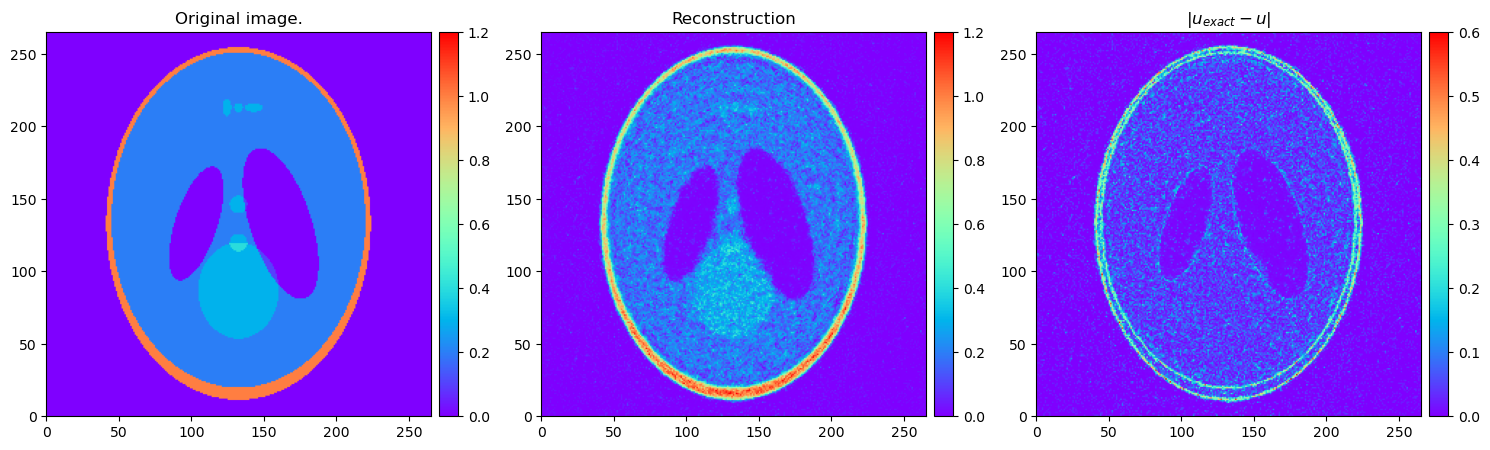

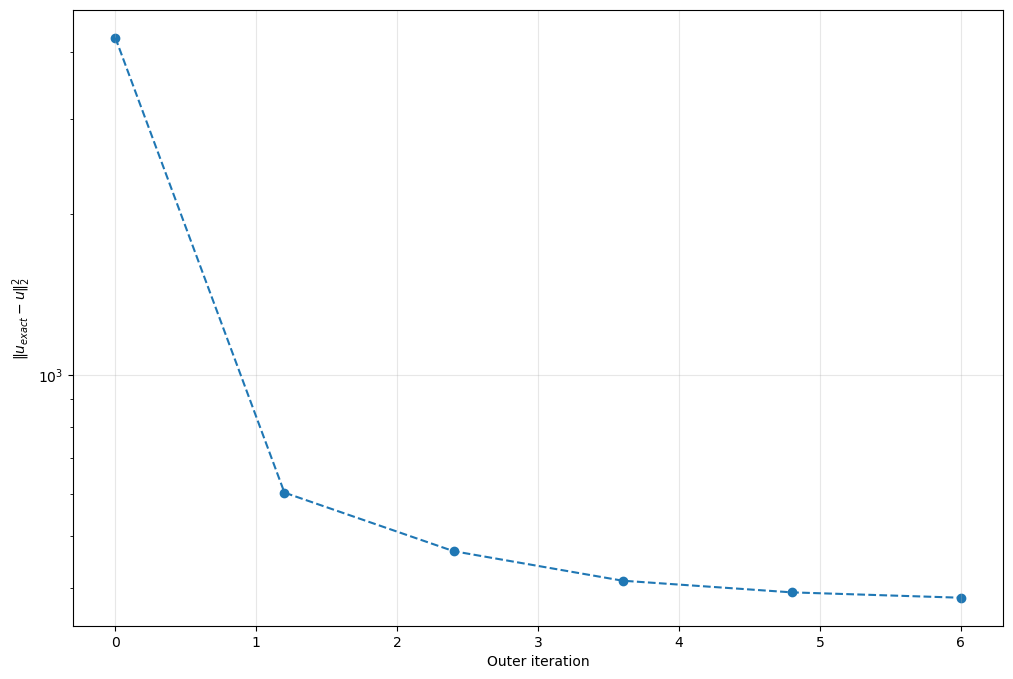

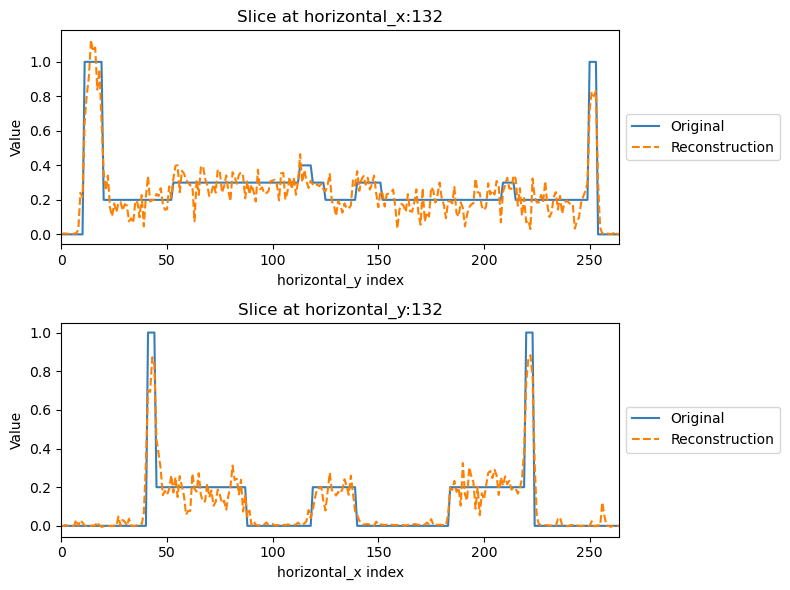

In [69]:
show2D([phantom, sol.abs(), (phantom-sol).abs()], ['Original image.', 'Reconstruction', '$|u_{exact} - u|$'], 
       num_cols=3,
       cmap='rainbow', 
       axis_labels=('', ''), 
       fix_range=[(0,1.2), (0,1.2),(0,0.6)])
x = np.linspace(0,len(sol_error), len(sol_error))

plt.figure(figsize=(12,8))
plt.semilogy(x, sol_error, linestyle='--')
plt.ylabel('$\|u_{exact} - u\|_2^2$')
plt.xlabel('Outer iteration')
plt.scatter(x,sol_error)
plt.grid(alpha=0.3)

show1D([phantom, sol], dataset_labels=['Original', 'Reconstruction'])